# 08 Multi Likelihood Classification example 

_[Estimated time of execution: 3 min]_

This notebook shows how to train a multi-output dataset with different likelihoods using MOGPTK.

We create two artificial data sets: one of classification where `y ∈ {0,1}`, and one of a sinusoidal regression. We will use [`mogptk.gpr.MultiOutputLikelihood`](https://games-uchile.github.io/mogptk/gpr/likelihood.html#mogptk.gpr.likelihood.MultiOutputLikelihood) to use a different likelihood for each channel. Specifically, we'll use the [`mogptk.gpr.BernoulliLikelihood`](https://games-uchile.github.io/mogptk/gpr/likelihood.html#mogptk.gpr.likelihood.BernoulliLikelihood) for classification, and [`mogptk.gpr.StudentTLikelihood`](https://games-uchile.github.io/mogptk/gpr/likelihood.html#mogptk.gpr.likelihood.StudentTLikelihood) for regression.

In [1]:
import numpy as np
import torch
import mogptk
from sklearn.datasets import make_classification, make_regression

torch.manual_seed(1);

Create the artificial data set.

(<Figure size 1200x1200 with 3 Axes>,
 array([[<Axes: xlabel='X', ylabel='Y'>],
        [<Axes: xlabel='X', ylabel='Y'>],
        [<Axes: xlabel='X', ylabel='Y'>]], dtype=object))

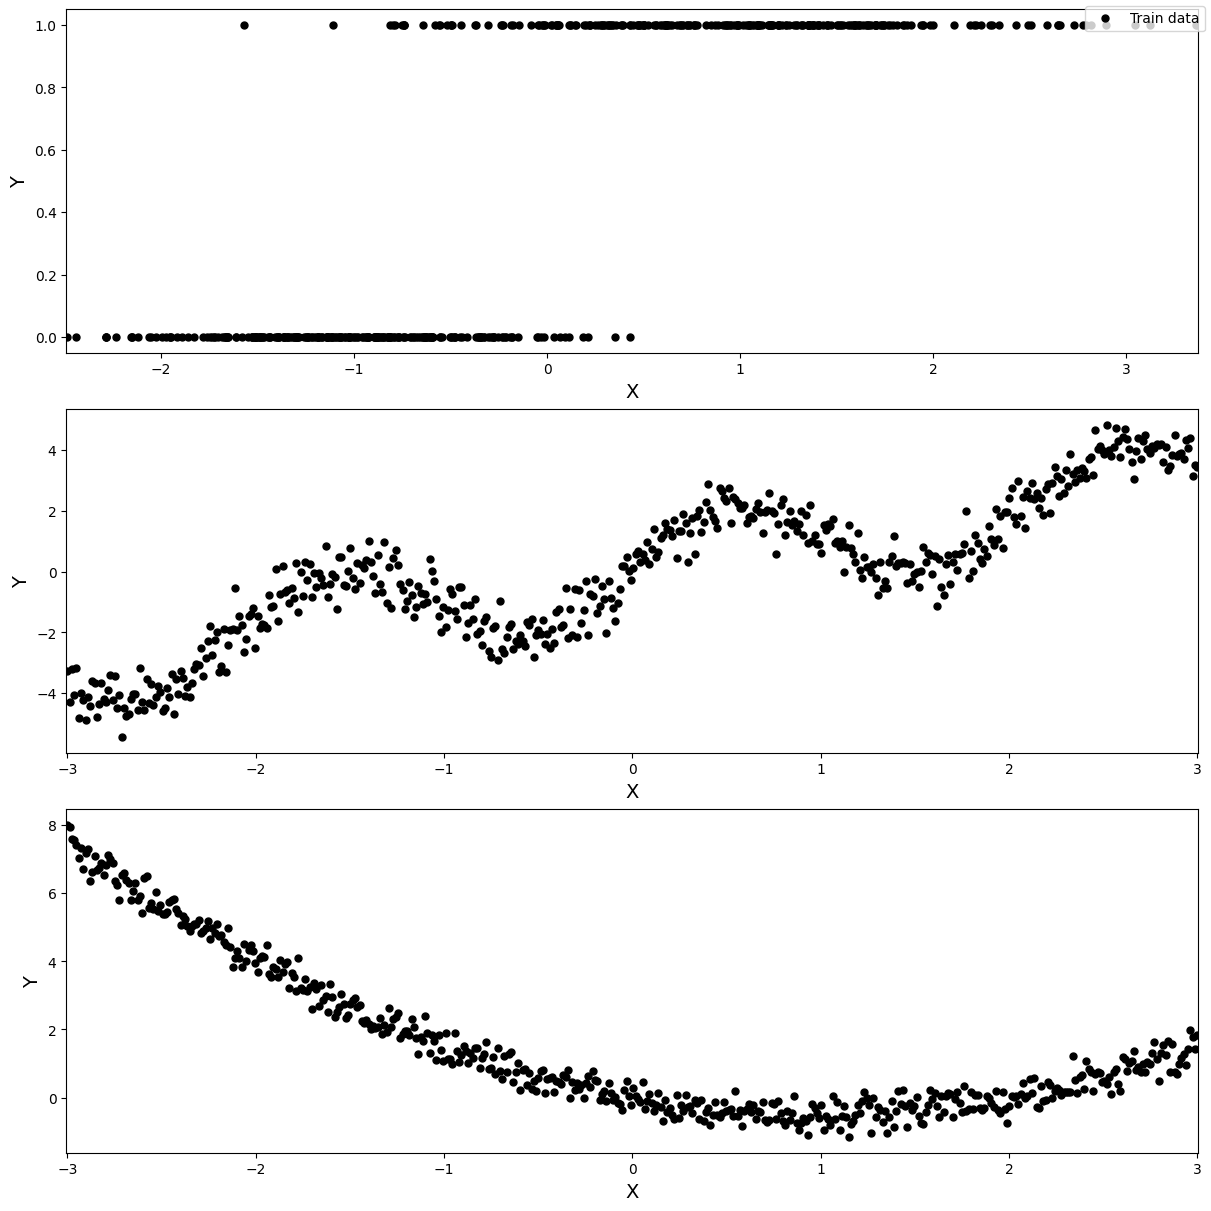

In [2]:
n = 500

# Salida 1
X1, y1 = make_classification(
    n_samples=n,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=1
)

X1 = X1.reshape(-1, 1)
y1 = y1.reshape(-1, 1)

# Salida 2
X2 = np.linspace(-3.0, 3.0, n).reshape(-1, 1)
y2 = X2 + 1.5 * np.sin(3.0 * X2) + 0.5*np.random.randn(n, 1)

# Salida 3
X3 = np.linspace(-3.0, 3.0, n).reshape(-1, 1)
y3 = 0.5 * X3**2 - X3 + 0.3 * np.random.randn(n, 1)

# Dataset multioutput (D = 3)
data = mogptk.DataSet(
    mogptk.Data(X1, y1),
    mogptk.Data(X2, y2),
    mogptk.Data(X3, y3),
)

data.plot()


Set up the model by using Hensman's Gaussian process inference, which allows us to use non-Gaussian likelihoods such as the [`mogptk.gpr.BernoulliLikelihood`](https://games-uchile.github.io/mogptk/gpr/likelihood.html#mogptk.gpr.likelihood.BernoulliLikelihood) and [`mogptk.gpr.StudentTLikelihood`](https://games-uchile.github.io/mogptk/gpr/likelihood.html#mogptk.gpr.likelihood.StudentTLikelihood) in this example. We will use the default squared exponential kernel for each channel and use the [`mogptk.gpr.multioutput.LinearModelOfCoregionalizationKernel`](https://games-uchile.github.io/mogptk/gpr/multioutput.html#mogptk.gpr.multioutput.LinearModelOfCoregionalizationKernel), also known as the LMC kernel, to learn the cross-channel features.

In [3]:
# Two latent processes (Q = 2)
k1 = mogptk.gpr.SquaredExponentialKernel()
k2 = mogptk.gpr.SquaredExponentialKernel()
# Linear Model of Coregionalization
kernel = mogptk.gpr.LinearModelOfCoregionalizationKernel(
    k1,
    k2,
    output_dims=3   # D = 3 salidas
)

In [4]:
likelihood = mogptk.gpr.MultiOutputLikelihood(
    mogptk.gpr.BernoulliLikelihood(),
     mogptk.gpr.StudentTLikelihood(),
    mogptk.gpr.StudentTLikelihood(),
)

In [5]:
inference = mogptk.Hensman(likelihood=likelihood)

In [6]:
model = mogptk.Model(data, kernel, inference=inference)

Training will be performed using the default Adam optimizer with a learning rate of `0.02` for a `500` iterations. We will additionally be measuring the error between the prediction and the target values using the mean absolute percentage error (MAPE), which is a relative error with respect to the target values.

Starting optimization using Adam
‣ Model: Hensman
  ‣ Kernel: LinearModelOfCoregionalizationKernel[SquaredExponentialKernel,SquaredExponentialKernel]
  ‣ Likelihood: [BernoulliLikelihood,StudentTLikelihood,StudentTLikelihood]
‣ Channels: 3
‣ Parameters: 1127262
‣ Training points: 1500
‣ Iterations: 1000
  1000/2000   0:00:00  loss=     1787.29  error=     94.3507
  1026/2000   0:00:10  loss=     1776.21  error=      92.773
  1053/2000   0:00:20  loss=     1769.69  error=     91.3467
  1079/2000   0:00:30  loss=     1766.96  error=     90.4432
  1105/2000   0:00:40  loss=     1764.63  error=     89.5406
  1131/2000   0:00:50  loss=     1762.54  error=      88.752
  1158/2000   0:01:00  loss=     1760.61  error=     88.0308
  1184/2000   0:01:10  loss=     1758.99  error=     87.4383
  1210/2000   0:01:20  loss=     1757.64  error=     86.7621
  1237/2000   0:01:30  loss=     1756.25  error=     86.3523
  1263/2000   0:01:40  loss=     1755.14  error=     86.0054
  1290/2000   0:01:50  l

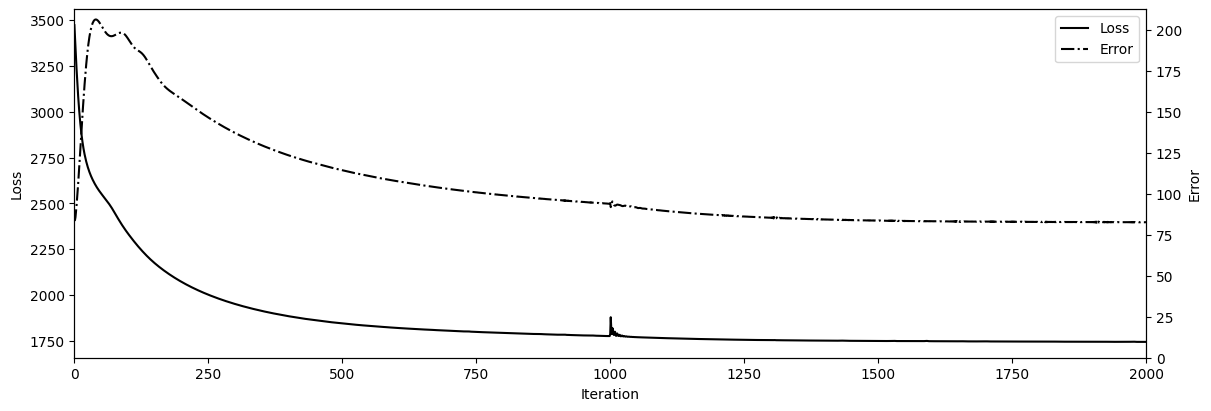

In [11]:
model.train(iters=1000, verbose=True, error='mape', lr=0.02, jit = False)
model.plot_losses();

In [1]:
model.plot_prediction(n=100000);

NameError: name 'model' is not defined